In [1]:
import sys
from pathlib import Path

# Add project root so imports like `from src...` work in notebooks/
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd

from src.run import Config
from src.grid import grid_search

import wandb

import matplotlib.pyplot as plt

In [ ]:
#The range of parameters to search over
grid = {
    "mr_window": [10, 20, 30, 50],
    "vol_q": [0.6, 0.7, 0.8],
    "fee_bps": [0.5, 1.0, 2.0],
}

symbols = ["SPY", "2330.TW"]
base_cfg = Config()

res = grid_search(symbols=symbols, base_cfg=base_cfg, grid=grid)
res.to_csv("reports/grid_results.csv", index=False)
res.head()

,Symbol,Strategy,FinalEquity,AnnRet,AnnVol,Sharpe,MaxDD,Calmar,param_mr_window,param_vol_q,param_fee_bps
0,SPY,Buy&Hold,6.572025,0.136310,0.170940,0.833541,-0.337172,0.404275,10,0.6,0.5
1,SPY,Momentum,0.951758,-0.003350,0.090008,0.008328,-0.397668,-0.008424,10,0.6,0.5
2,SPY,Mean Reversion,2.470379,0.063302,0.135141,0.522099,-0.382131,0.165656,10,0.6,0.5
3,SPY,Mean Reversion with Regime,1.936700,0.045882,0.074120,0.642380,-0.170304,0.269414,10,0.6,0.5
4,2330.TW,Buy&Hold,27.586594,0.262697,0.252545,1.049983,-0.447990,0.586390,10,0.6,0.5


In [4]:
res = pd.read_csv("reports/grid_results.csv")
res.columns

Index(['Symbol', 'Strategy', 'FinalEquity', 'AnnRet', 'AnnVol', 'Sharpe',
       'MaxDD', 'Calmar', 'param_mr_window', 'param_vol_q', 'param_fee_bps'],
      dtype='str')

In [5]:
res["Strategy"].unique()

<ArrowStringArray>
['Buy&Hold', 'Momentum', 'Mean Reversion', 'Mean Reversion with Regime']
Length: 4, dtype: str

In [13]:
res = pd.read_csv("reports/grid_results.csv")

res["Strategy"] = res["Strategy"].astype(str).str.strip()

strategy_map = {
    "Buy&Hold": "Buy&Hold",
    "Momentum": "MOM_longonly",
    "Mean Reversion": "MR_longonly",
    "Mean Reversion with Regime": "MR_lowvol_filter",
}
res["StrategyKey"] = res["Strategy"].map(strategy_map).fillna(res["Strategy"])

target = res[res["StrategyKey"] == "MR_lowvol_filter"].copy()

best = (
    target.sort_values(["Symbol", "Sharpe", "MaxDD"], ascending=[True, False, False])
    .groupby("Symbol")
    .head(5)
)

best[["Symbol", "StrategyKey", "Sharpe", "MaxDD", "Calmar", "param_mr_window", 
      "param_vol_q", "param_fee_bps"]]

,Symbol,StrategyKey,Sharpe,MaxDD,Calmar,param_mr_window,param_vol_q,param_fee_bps
199,2330.TW,MR_lowvol_filter,0.864754,-0.359704,0.292103,30,0.8,0.5
207,2330.TW,MR_lowvol_filter,0.855177,-0.360025,0.288178,30,0.8,1.0
151,2330.TW,MR_lowvol_filter,0.840110,-0.274218,0.307699,30,0.6,0.5
215,2330.TW,MR_lowvol_filter,0.836012,-0.360666,0.280363,30,0.8,2.0
159,2330.TW,MR_lowvol_filter,0.830258,-0.275020,0.302812,30,0.6,1.0
267,SPY,MR_lowvol_filter,0.882145,-0.114787,0.563041,50,0.8,0.5
275,SPY,MR_lowvol_filter,0.871634,-0.114876,0.555375,50,0.8,1.0
243,SPY,MR_lowvol_filter,0.865867,-0.114787,0.479090,50,0.7,0.5
251,SPY,MR_lowvol_filter,0.854939,-0.114876,0.472241,50,0.7,1.0
283,SPY,MR_lowvol_filter,0.850594,-0.115055,0.540094,50,0.8,2.0


In [7]:
wandb.init(project="quant-regime-project", name="grid-search")
wandb.log({"grid_results": wandb.Table(dataframe=res)})

#We can also put the best results into a table and log it
wandb.log({"best_mr_lowvol": wandb.Table(dataframe=best)})

wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/luchengliang/.netrc.
wandb: Currently logged in as: lianglu3366 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


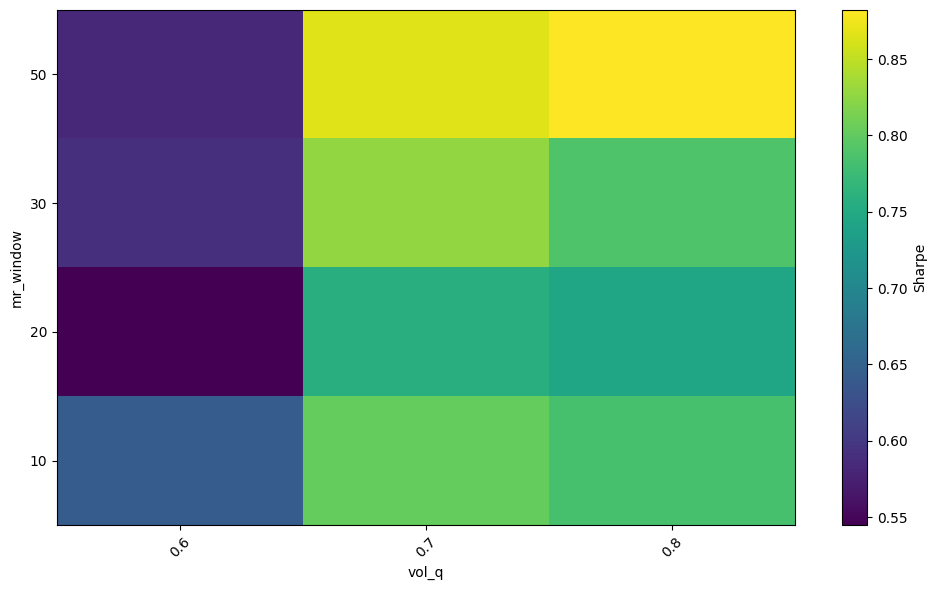

Saved: reports/figures/SPY_heatmap_sharpe_fee0.5.png


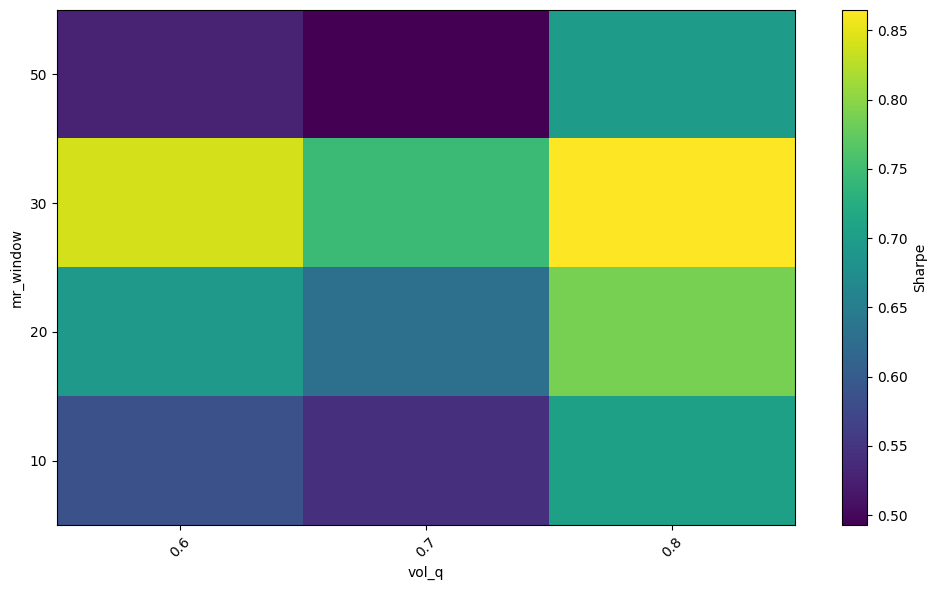

Saved: reports/figures/2330.TW_heatmap_sharpe_fee0.5.png


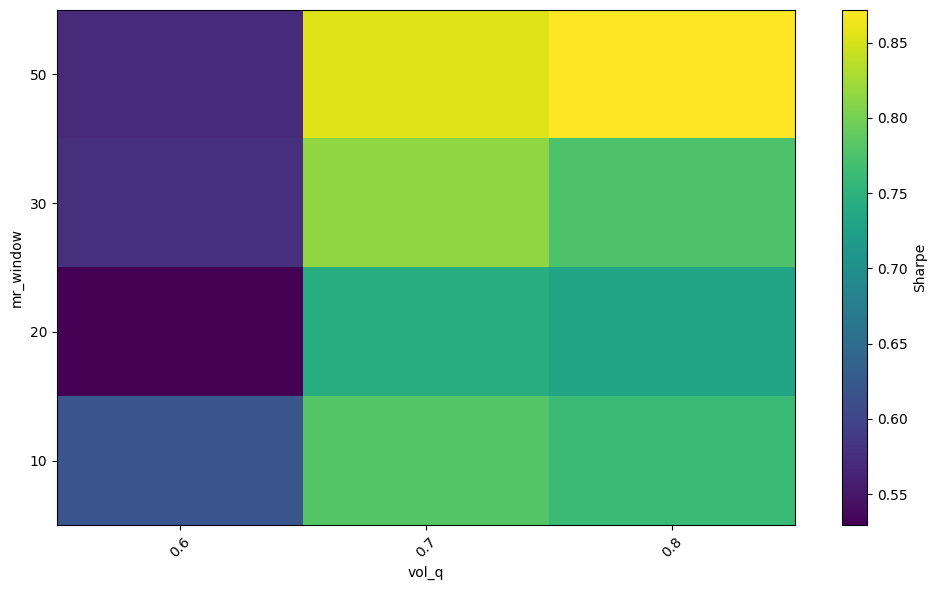

Saved: reports/figures/SPY_heatmap_sharpe_fee1.0.png


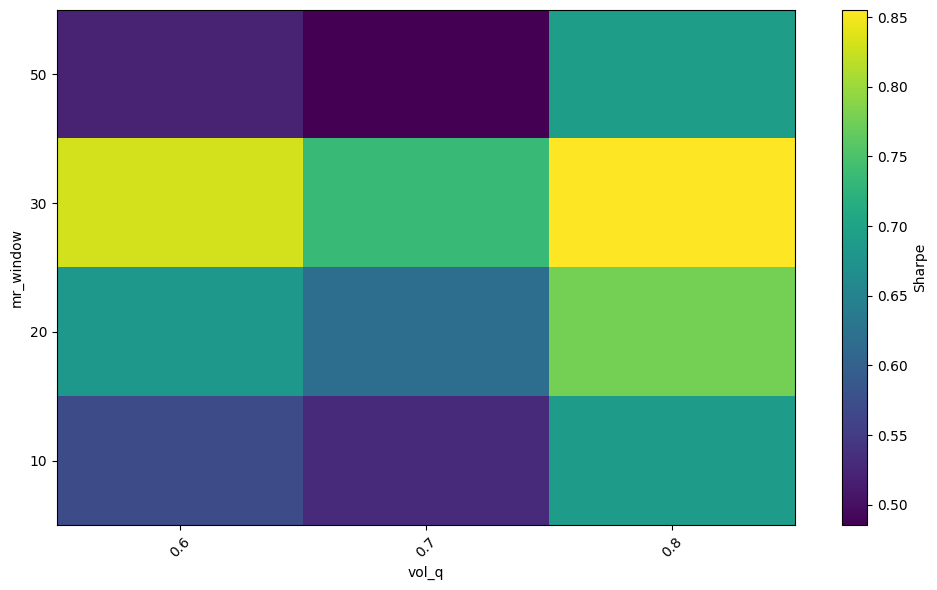

Saved: reports/figures/2330.TW_heatmap_sharpe_fee1.0.png


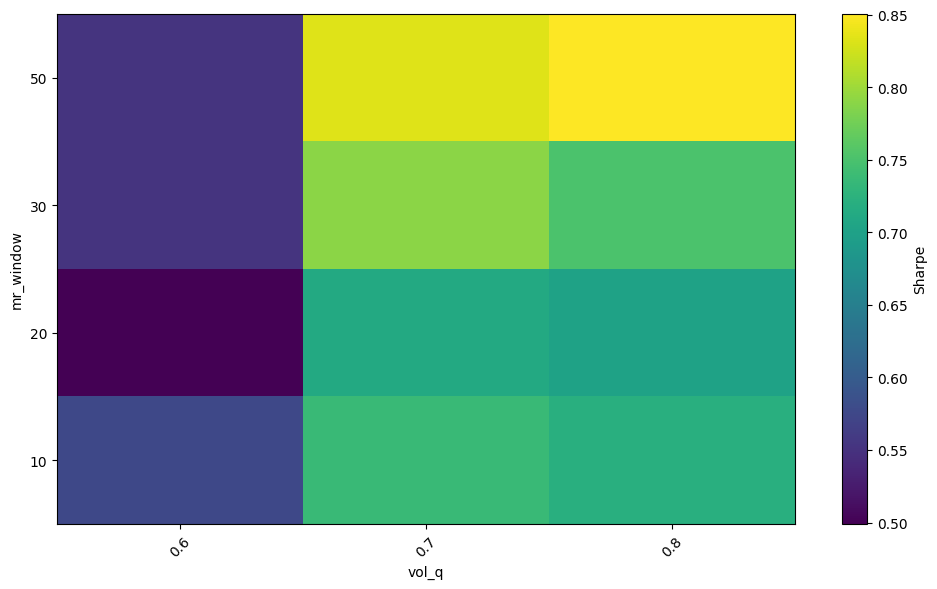

Saved: reports/figures/SPY_heatmap_sharpe_fee2.0.png


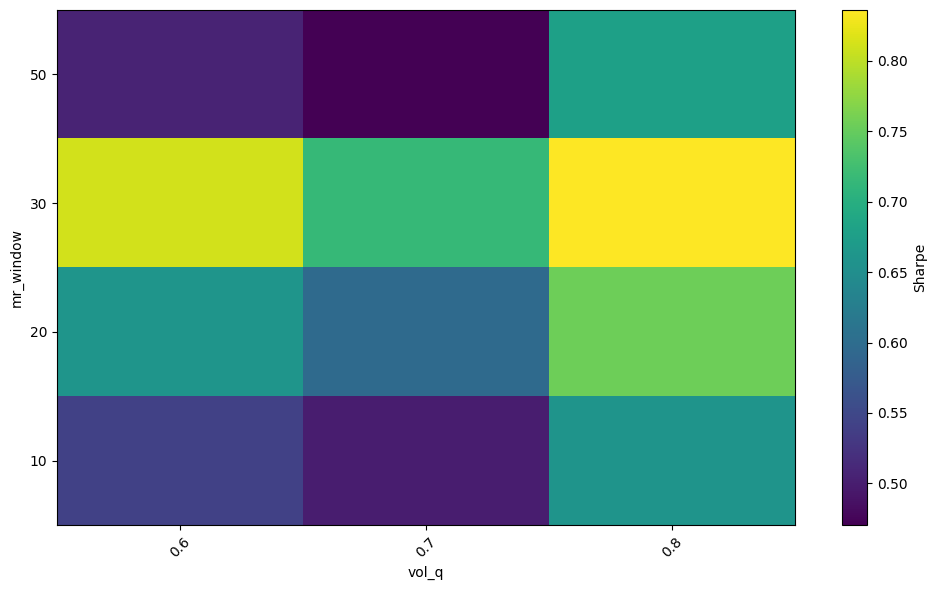

Saved: reports/figures/2330.TW_heatmap_sharpe_fee2.0.png


In [15]:
#from pyarrow.compute import RoundTemporalOptions


res = pd.read_csv("reports/grid_results.csv")
res["Strategy"] = res["Strategy"].astype(str).str.strip()

strategy_map = {
    "Buy&Hold": "Buy&Hold",
    "Momentum": "MOM_longonly",
    "Mean Reversion": "MR_longonly",
    "Mean Reversion with Regime": "MR_lowvol_filter",
}
res["StrategyKey"] = res["Strategy"].map(strategy_map).fillna(res["Strategy"])

target = res[res["StrategyKey"] == "MR_lowvol_filter"].copy()

def plot_heatmap(symbol: str, fee_bps: float = 0.5):
    sub = target[(target["Symbol"] == symbol) & (target["param_fee_bps"] == fee_bps)].copy()
    
    #pivot: rows=mr_window, cols=vol_q, values=Sharpe
    pivot = (sub.pivot_table(
        index="param_mr_window",
        columns="param_vol_q",
        values="Sharpe",
        aggfunc="mean"
    ).sort_index().sort_index(axis=1))
    
    plt.figure(figsize=(10, 6))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns], rotation=45)
    plt.yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
    plt.colorbar(label="Sharpe")
    plt.xlabel("vol_q")
    plt.ylabel("mr_window")
    plt.tight_layout()
    
    out = f"reports/figures/{symbol}_heatmap_sharpe_fee{fee_bps}.png"
    plt.savefig(out, dpi=250)
    plt.show()
    print("Saved:", out)
    
for fee in [0.5, 1.0, 2.0]:    
    plot_heatmap("SPY", fee_bps=fee)
    plot_heatmap("2330.TW", fee_bps=fee)